# 課題0710

そのまま課題ファイルで編集しないでください。課題ファイルを複製してから課題を回答してください。

In [5]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------------------------------------- - 8.9/9.3 MB 45.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 40.8 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.9 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 41.5 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   -

In [11]:
import pandas as pd

df = pd.read_csv(
    "https://raw.githubusercontent.com/lvzeyu/css_tohoku/master/css_tohoku/draft/Data/titanic.csv"
)

## 課題1

以下の図を再現してください

- 年齢の分布を、異なる階級幅を使って、4つのサブプロットをわけて描画する
   - 階級幅を適当で決めてよい
- 各サブプロットには、
    - x軸ラベル、y軸ラベル、サブプロット番号(a-d)を指定する
    - 水平方向のグリッド線を追加する
    - ヒストグラムの色を`lightblue`に変更する

![](./Figure1.png)

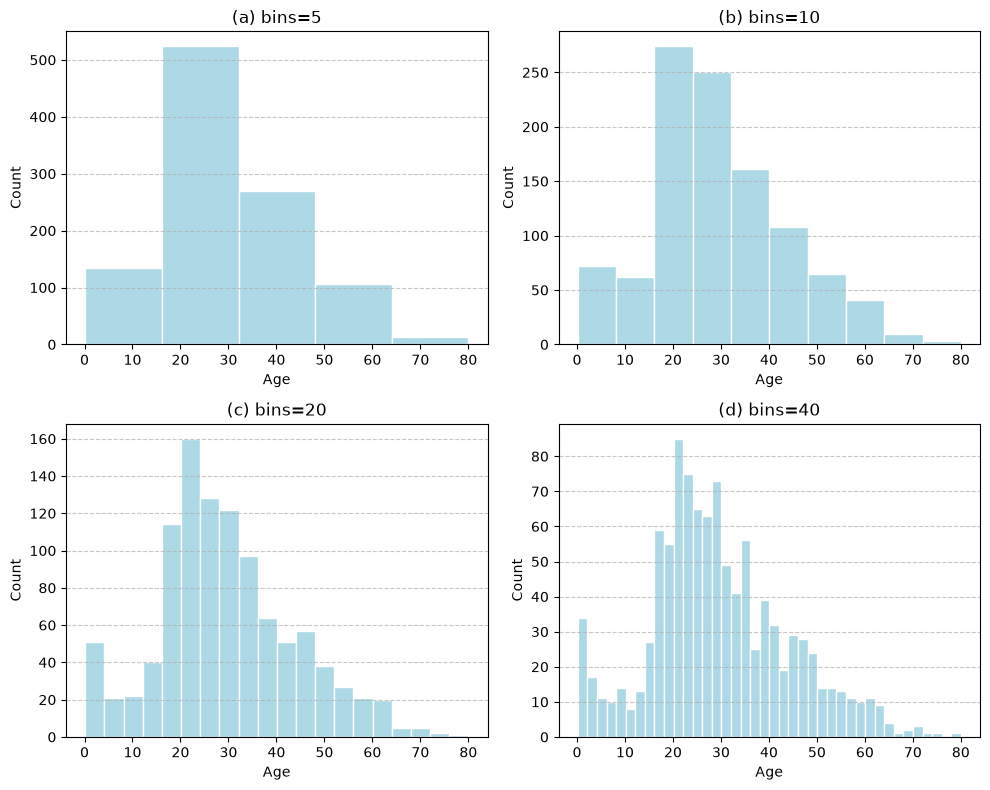

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. データを再度読み込み
df = pd.read_csv(
    "https://raw.githubusercontent.com/lvzeyu/css_tohoku/master/css_tohoku/draft/Data/titanic.csv"
)

# 2. 列名が 'Age' か 'age' か判定して取得
age_col = "Age" if "Age" in df.columns else "age"

# 3. 2x2 のサブプロットを作成
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

bins_list = [5, 10, 20, 40]
labels = ["a", "b", "c", "d"]

for ax, bins_val, label in zip(axes.flatten(), bins_list, labels):
    ax.hist(
        df[age_col].dropna(),
        bins=bins_val,
        color="lightblue",
        edgecolor="white",
    )
    ax.set_xlabel("Age")
    ax.set_ylabel("Count")
    ax.set_title(f"({label}) bins={bins_val}")
    ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

## 課題2

以下の図を再現してください

- 男性乗客と女性乗客の年齢の分布をそれぞれ描画する
- 全乗客の年齢分布を示す灰色ヒストグラムも描画する
- 図のタイトル、x軸ラベル、y軸ラベル、凡例を設定する

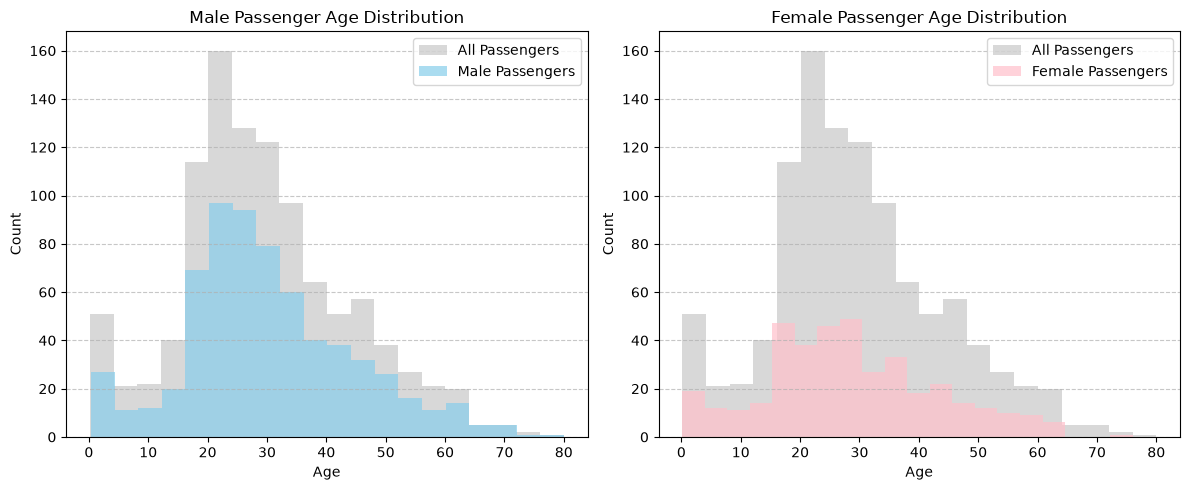

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# 列名と性別列の判定
age_col = "Age" if "Age" in df.columns else "age"
sex_col = "Sex" if "Sex" in df.columns else "sex"

# データの準備
age_data = df[age_col].dropna()
male_age = df[df[sex_col].isin(["male", "Male"])][age_col].dropna()
female_age = df[df[sex_col].isin(["female", "Female"])][age_col].dropna()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 男性乗客と全乗客の比較
ax[0].hist(age_data, bins=20, color="gray", alpha=0.3, label="All Passengers")
ax[0].hist(male_age, bins=20, color="skyblue", alpha=0.7, label="Male Passengers")
ax[0].set_title("Male Passenger Age Distribution")
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Count")
ax[0].legend()
ax[0].grid(axis="y", linestyle="--", alpha=0.7)

# 女性乗客と全乗客の比較
ax[1].hist(age_data, bins=20, color="gray", alpha=0.3, label="All Passengers")
ax[1].hist(female_age, bins=20, color="pink", alpha=0.7, label="Female Passengers")
ax[1].set_title("Female Passenger Age Distribution")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Count")
ax[1].legend()
ax[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

![](./Figure2.png)